In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(40)

mean = [0, 0] # 既然是讲原理，我们直接假设已经去中心化了
cov = [[10, 8], [8, 10]]  # 协方差矩阵：对角线是各自方差，非对角线是协方差
data = np.random.multivariate_normal(mean, cov, 100)

cov_matrix=np.cov(data.T)

cov_matrix

array([[12.16687561, 10.10281918],
       [10.10281918, 11.12520565]])

In [9]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\n特征值 (Variance的大小):", eigenvalues)
print("特征向量 (数据的骨架方向):\n", eigenvectors)
# 排序：确保我们先看最大的特征值
# argsort 从小到大排，我们取反[::-1]变成从大到小
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\n--- 排序后 ---")
print("第一主成分 (最大特征值):", eigenvalues[0])
print("第一主成分方向:", eigenvectors[:, 0])


特征值 (Variance的大小): [21.76227631  1.52980495]
特征向量 (数据的骨架方向):
 [[ 0.72508105 -0.68866354]
 [ 0.68866354  0.72508105]]

--- 排序后 ---
第一主成分 (最大特征值): 21.762276307956895
第一主成分方向: [0.72508105 0.68866354]


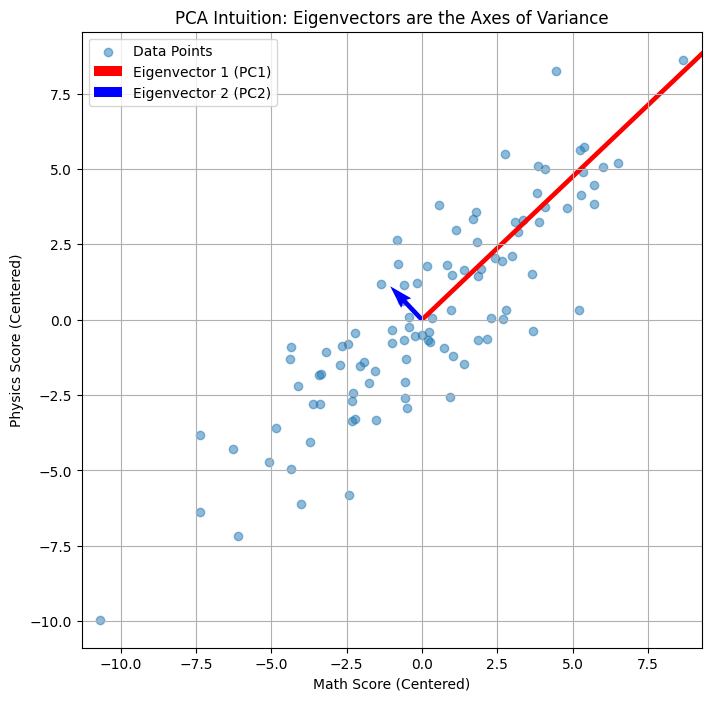

In [10]:
# 绘图设置
plt.figure(figsize=(8, 8))
# 画散点
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Data Points')

# 画特征向量
# 原点
origin = [0, 0]

# 咱们用箭头把特征向量画出来
# 向量1 (第一主成分) - 红色，长一点
plt.quiver(*origin, 
           eigenvectors[0, 0] * eigenvalues[0], # x分量 * 特征值(作为长度)
           eigenvectors[1, 0] * eigenvalues[0], # y分量 * 特征值(作为长度)
           color='r', scale=1, scale_units='xy', angles='xy', label='Eigenvector 1 (PC1)')

# 向量2 (第二主成分) - 蓝色，短一点
plt.quiver(*origin, 
           eigenvectors[0, 1] * eigenvalues[1], 
           eigenvectors[1, 1] * eigenvalues[1], 
           color='b', scale=1, scale_units='xy', angles='xy', label='Eigenvector 2 (PC2)')

plt.title('PCA Intuition: Eigenvectors are the Axes of Variance')
plt.xlabel('Math Score (Centered)')
plt.ylabel('Physics Score (Centered)')
plt.grid(True)
plt.axis('equal') # 保证x和y轴比例一致，不然向量看着不像垂直的
plt.legend()
plt.show()

In [11]:
# 选取第一主成分 (取第一列)
top_eigenvector = eigenvectors[:, 0].reshape(-1, 1)

# 投影 (矩阵乘法)
# (100x2) dot (2x1) -> (100x1)
transformed_data = np.dot(data, top_eigenvector)

print("原始数据形状:", data.shape)     # (100, 2)
print("降维后数据形状:", transformed_data.shape) # (100, 1)
# 现在 transformed_data 就是一维数组了，代表每个学生在“理科综合能力”（新维度）上的得分

原始数据形状: (100, 2)
降维后数据形状: (100, 1)
